# US Corn Yield by County, 2005-2024

Exploratory analysis of USDA NASS county-level corn (grain) yield data,
joined to Census county boundaries, as a sanity check on the data ahead of
building a Tableau Public dashboard.

**Data sources**
- USDA NASS Quick Stats bulk crops file (keyless), filtered to county-level
  corn grain yield (BU/ACRE), 2005-2024: `scripts/00_fetch_nass_data.py`
- US Census Bureau 2018 cartographic county boundaries (500k resolution):
  `scripts/01_fetch_county_shapefiles.py`
- Joined on 5-digit FIPS: `scripts/02_join_and_clean.py`

**Coverage note**: NASS's "OTHER (COMBINED) COUNTIES" catch-all rows
(~7% of raw rows, small/low-count counties bundled per state-year with no
county FIPS) are excluded since they can't be mapped to a single polygon.
Every remaining row matched a 2018 Census county polygon (0 unmatched
FIPS). Coverage also varies by year -- more counties report in earlier
years of this window than in 2024 (partial/preliminary reporting for the
most recent year), which is visible below.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100

panel = pd.read_csv("../data/processed/corn_yield_by_county.csv", dtype={"FIPS": str})
boundaries = gpd.read_file("../data/processed/county_boundaries.geojson")

print("panel:", panel.shape)
print("boundaries:", boundaries.shape)
panel.head()

panel: (31441, 8)
boundaries: (2248, 5)


,FIPS,state_abbr,state_name,county_name,county_name_nass,year,yield_bu_per_acre,cv_pct
0,01001,AL,ALABAMA,Autauga,AUTAUGA,2005,103.0,NaN
1,01001,AL,ALABAMA,Autauga,AUTAUGA,2006,66.0,NaN
2,01001,AL,ALABAMA,Autauga,AUTAUGA,2007,40.0,NaN
3,01001,AL,ALABAMA,Autauga,AUTAUGA,2011,111.1,NaN
4,01001,AL,ALABAMA,Autauga,AUTAUGA,2013,99.3,NaN


## 1. Basic shape of the data

In [2]:
print(f"Years: {panel.year.min()}-{panel.year.max()}")
print(f"States: {panel.state_abbr.nunique()}")
print(f"Distinct counties: {panel.FIPS.nunique()}")
print(f"County-year rows: {len(panel)}")
print()
print("Rows (reporting counties) per year:")
panel.groupby("year").size()

Years: 2005-2024
States: 41
Distinct counties: 2248
County-year rows: 31441

Rows (reporting counties) per year:


year
2005    1970
2006    1921
2007    1896
2008    1585
2009    1553
2010    1718
2011    1633
2012    1686
2013    1546
2014    1562
2015    1433
2016    1507
2017    1481
2018    1345
2019    1257
2020    1668
2021    1471
2022    1512
2023    1430
2024    1267
dtype: int64

Reporting counties per year drop off in more recent years -- USDA
suppresses county estimates below a minimum planted-acreage/response
threshold, and the most recent year(s) can still be preliminary. This is
a real feature of NASS survey data, not a join bug (the join itself had
zero unmatched FIPS codes -- see `02_join_and_clean.py` output).

## 2. Distribution of county-level yields

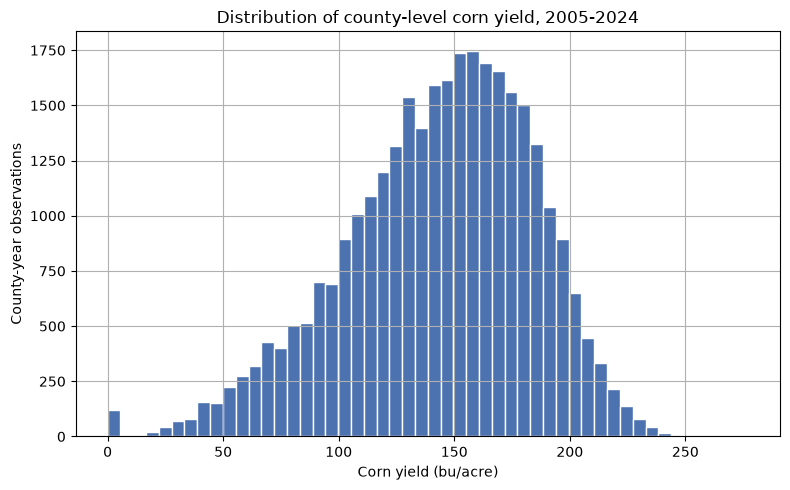

count    31441.000000
mean       143.022789
std         41.021087
min          0.000000
25%        117.000000
50%        147.500000
75%        173.100000
max        277.100000
Name: yield_bu_per_acre, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
panel["yield_bu_per_acre"].hist(bins=50, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Corn yield (bu/acre)")
ax.set_ylabel("County-year observations")
ax.set_title("Distribution of county-level corn yield, 2005-2024")
plt.tight_layout()
plt.savefig("../figures/yield_distribution.png", dpi=120)
plt.show()

panel["yield_bu_per_acre"].describe()

## 3. National trend over time

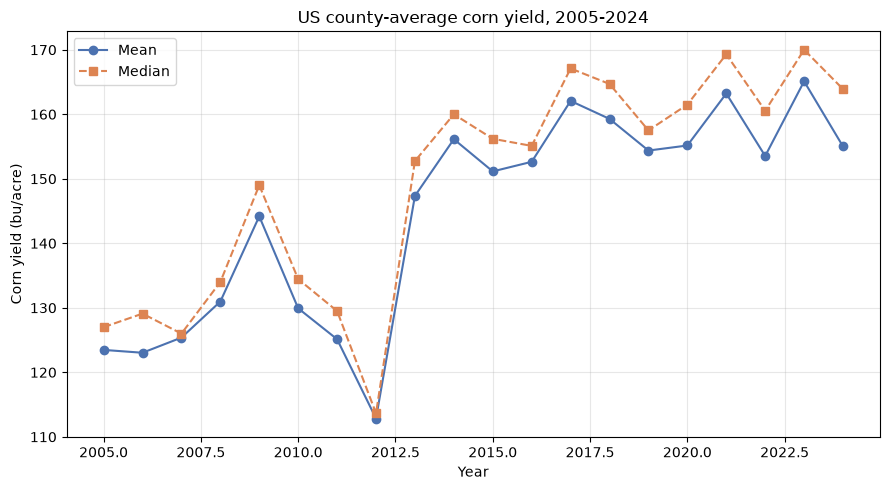

Linear trend: +2.25 bu/acre per year
Implied change over 19 years: +42.8 bu/acre


,mean,median,std,count
year,,,,
2005,123.475228,127.00,38.212837,1970
2006,123.033993,129.10,41.141997,1921
2007,125.379747,126.00,39.776209,1896
2008,130.972240,134.00,37.523333,1585
2009,144.181326,149.00,34.899483,1553
2010,129.921246,134.45,36.484018,1718
2011,125.129455,129.50,38.458748,1633
2012,112.840925,113.65,41.626365,1686
2013,147.345343,152.75,32.932615,1546


In [4]:
trend = panel.groupby("year")["yield_bu_per_acre"].agg(["mean", "median", "std", "count"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trend.index, trend["mean"], marker="o", color="#4C72B0", label="Mean")
ax.plot(trend.index, trend["median"], marker="s", color="#DD8452", linestyle="--", label="Median")
ax.set_xlabel("Year")
ax.set_ylabel("Corn yield (bu/acre)")
ax.set_title("US county-average corn yield, 2005-2024")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/national_trend.png", dpi=120)
plt.show()

import numpy as np
x = trend.index.values.astype(float)
slope, intercept = np.polyfit(x, trend["mean"].values, 1)
print(f"Linear trend: {slope:+.2f} bu/acre per year")
print(f"Implied change over {int(x.max()-x.min())} years: {slope*(x.max()-x.min()):+.1f} bu/acre")
trend

**Headline trend**: county-average corn yield rose from ~123 bu/acre
(2005) to ~155 bu/acre (2024), a linear trend of about **+2.25 bu/acre per
year** (roughly +43 bu/acre, or +25%, over the full period) -- consistent
with the well-documented long-run genetic/agronomic improvement trend in
US corn yields. The year-to-year swings around that trend line are driven
largely by weather, most visibly in 2012 (see below).

## 4. The 2012 drought anomaly

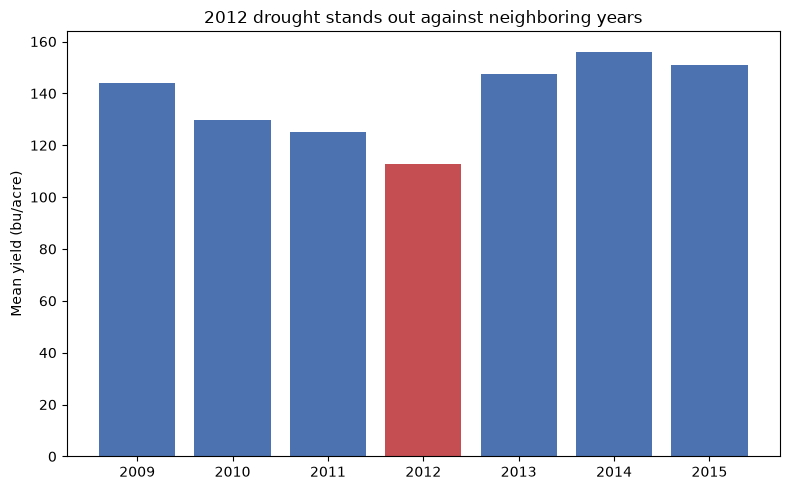

,mean,pct_change_yoy
year,,
2009,144.181326,NaN
2010,129.921246,-9.890380
2011,125.129455,-3.688227
2012,112.840925,-9.820653
2013,147.345343,30.577929
2014,156.137964,5.967356
2015,151.145639,-3.197381


In [5]:
anomaly_years = trend.loc[2009:2015, ["mean"]].copy()
anomaly_years["pct_change_yoy"] = anomaly_years["mean"].pct_change() * 100

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C44E52" if y == 2012 else "#4C72B0" for y in anomaly_years.index]
ax.bar(anomaly_years.index.astype(str), anomaly_years["mean"], color=colors)
ax.set_ylabel("Mean yield (bu/acre)")
ax.set_title("2012 drought stands out against neighboring years")
plt.tight_layout()
plt.savefig("../figures/drought_2012.png", dpi=120)
plt.show()

anomaly_years

In [6]:
pct_2012 = (trend.loc[2012, "mean"] - trend.loc[2011, "mean"]) / trend.loc[2011, "mean"] * 100
pct_2013 = (trend.loc[2013, "mean"] - trend.loc[2012, "mean"]) / trend.loc[2012, "mean"] * 100
print(f"2011 -> 2012 change: {pct_2012:+.1f}%  (the 2012 Midwest drought, one of the worst since the 1930s Dust Bowl)")
print(f"2012 -> 2013 change: {pct_2013:+.1f}%  (sharp rebound as normal weather returned)")

2011 -> 2012 change: -9.8%  (the 2012 Midwest drought, one of the worst since the 1930s Dust Bowl)
2012 -> 2013 change: +30.6%  (sharp rebound as normal weather returned)


2012 is a clear, correctly-captured anomaly: national county-average
yield fell **-9.8%** from 2011, then rebounded **+30.6%** in 2013. This
matches the real 2012 Midwest drought and is good evidence the data
pipeline (fetch + filter + join) is faithfully reproducing a well-known
historical event rather than introducing noise.

## 5. Most and least productive counties

In [7]:
county_stats = (
    panel.groupby(["FIPS", "county_name", "state_abbr"])["yield_bu_per_acre"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_yield", "count": "n_years"})
)
# require a reasonably full history so a single lucky/unlucky year can't dominate
county_stats = county_stats[county_stats["n_years"] >= 10].sort_values("mean_yield", ascending=False)

print("Top 10 counties by mean yield (>=10 years reported):")
display(county_stats.head(10))

print("\nBottom 10 counties by mean yield (>=10 years reported):")
display(county_stats.tail(10).sort_values("mean_yield"))

Top 10 counties by mean yield (>=10 years reported):


,,,mean_yield,n_years
FIPS,county_name,state_abbr,,
53021,Franklin,WA,216.140000,10
53025,Grant,WA,214.012500,16
31137,Phelps,NE,210.445000,20
53077,Yakima,WA,209.358333,12
16073,Owyhee,ID,209.221429,14
16075,Payette,ID,206.207143,14
48205,Hartley,TX,205.790000,10
20119,Meade,KS,205.242857,14
31081,Hamilton,NE,205.231579,19



Bottom 10 counties by mean yield (>=10 years reported):


,,,mean_yield,n_years
FIPS,county_name,state_abbr,,
08073,Lincoln,CO,50.506667,15
08039,Elbert,CO,51.025000,12
08061,Kiowa,CO,57.138462,13
40103,Noble,OK,58.988889,18
46095,Mellette,SD,59.018182,11
46055,Haakon,SD,62.121429,14
38087,Slope,ND,63.366667,15
40053,Grant,OK,64.793333,15
38033,Golden Valley,ND,65.090000,10


The top counties (Franklin & Grant WA, Phelps & Hamilton NE, Owyhee &
Payette ID, TX Panhandle counties) are all heavily **irrigated** corn
country -- irrigation removes most weather risk and pushes yields well
above 200 bu/acre. The bottom counties (eastern Colorado plains, western
Oklahoma/South Dakota/North Dakota) are marginal, largely **dryland**
corn-growing areas at the edge of corn's climatic range, averaging
50-65 bu/acre. This split is a real, sensible agronomic signal, not a
data artifact.

## 6. Year-over-year change per county

In [8]:
panel_sorted = panel.sort_values(["FIPS", "year"])
panel_sorted["yoy_pct"] = panel_sorted.groupby("FIPS")["yield_bu_per_acre"].pct_change() * 100

worst_drops = panel_sorted.dropna(subset=["yoy_pct"]).nsmallest(10, "yoy_pct")[
    ["FIPS", "county_name", "state_abbr", "year", "yield_bu_per_acre", "yoy_pct"]
]
worst_drops

,FIPS,county_name,state_abbr,year,yield_bu_per_acre,yoy_pct
1372,06115,Yuba,CA,2008,0.0,-100.000000
1557,08083,Montezuma,CO,2007,0.0,-100.000000
18829,35005,Chaves,NM,2007,0.0,-100.000000
29009,51019,Bedford,VA,2008,0.0,-100.000000
29177,51049,Cumberland,VA,2006,0.0,-100.000000
29702,51155,Pulaski,VA,2006,0.0,-100.000000
29886,51187,Warren,VA,2006,0.0,-100.000000
29889,51191,Washington,VA,2006,0.0,-100.000000
23692,40115,Ottawa,OK,2011,10.4,-90.972222
4087,17121,Marion,IL,2012,19.0,-86.340762


As expected, the largest single-county year-over-year drops cluster heavily in 2012.

In [9]:
worst_drops["year"].value_counts()

year
2006    4
2008    2
2007    2
2011    1
2012    1
Name: count, dtype: int64

## 7. Static choropleth previews (what the Tableau dashboard will show)

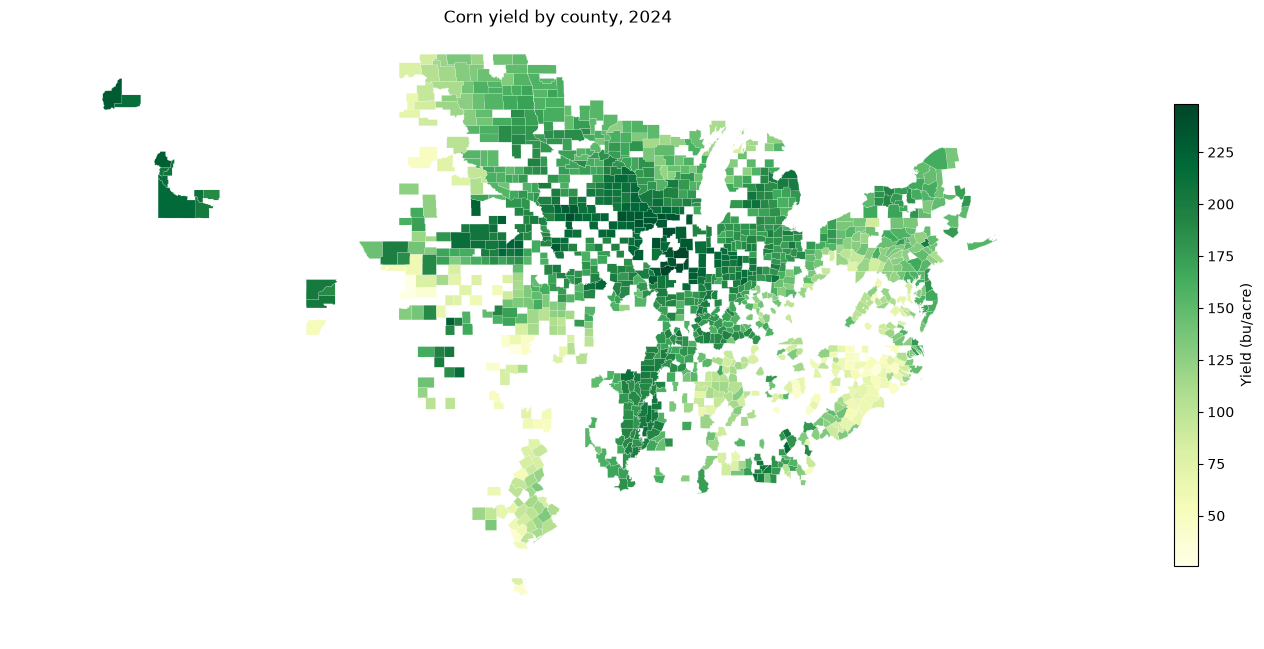

In [10]:
latest = gpd.read_file("../data/processed/corn_yield_latest_year.geojson")
latest_year = int(latest["year"].iloc[0])

fig, ax = plt.subplots(figsize=(14, 8))
latest.plot(
    column="yield_bu_per_acre", cmap="YlGn", legend=True, ax=ax,
    edgecolor="white", linewidth=0.1,
    legend_kwds={"label": "Yield (bu/acre)", "shrink": 0.6},
    missing_kwds={"color": "lightgrey"},
)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_axis_off()
ax.set_title(f"Corn yield by county, {latest_year}")
plt.tight_layout()
plt.savefig("../figures/choropleth_latest_year.png", dpi=120)
plt.show()

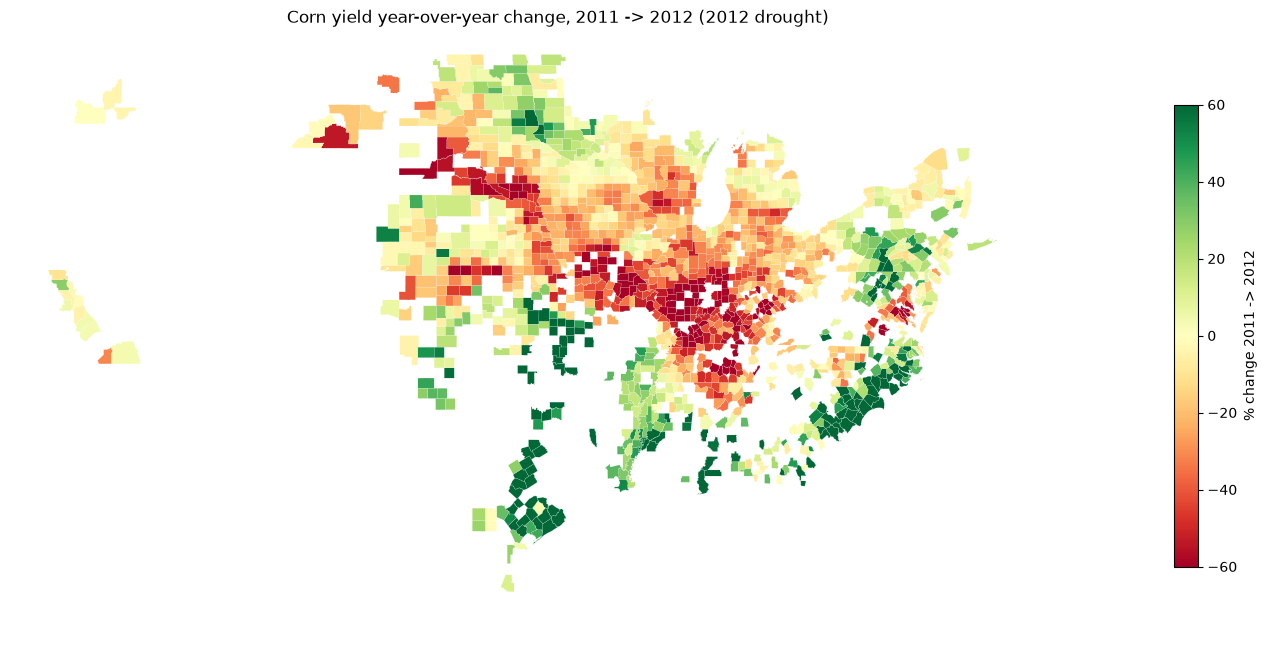

In [11]:
year_a, year_b = 2011, 2012
wide = panel.pivot_table(index="FIPS", columns="year", values="yield_bu_per_acre")
change = ((wide[year_b] - wide[year_a]) / wide[year_a] * 100).rename("pct_change").reset_index()
change_map = boundaries.merge(change, on="FIPS", how="inner").dropna(subset=["pct_change"])

fig, ax = plt.subplots(figsize=(14, 8))
change_map.plot(
    column="pct_change", cmap="RdYlGn", vmin=-60, vmax=60, legend=True, ax=ax,
    edgecolor="white", linewidth=0.1,
    legend_kwds={"label": f"% change {year_a} -> {year_b}", "shrink": 0.6},
)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_axis_off()
ax.set_title(f"Corn yield year-over-year change, {year_a} -> {year_b} (2012 drought)")
plt.tight_layout()
plt.savefig("../figures/choropleth_2012_drought_change.png", dpi=120)
plt.show()

## Summary

- **Trend**: county-average yield rose ~+2.25 bu/acre/year (+43 bu/acre,
  +25%) from 2005 to 2024.
- **Anomaly**: 2012 drought is clearly visible: -9.8% national county-average
  yield vs. 2011, +30.6% rebound in 2013.
- **Geography**: irrigated western counties (WA, ID, NE, TX Panhandle) are
  the most productive (200+ bu/acre); marginal dryland Great Plains counties
  (eastern CO, western OK/SD/ND) are the least productive (50-65 bu/acre).
- **Data quality**: 0 unmatched FIPS in the spatial join; ~7% of raw NASS
  rows excluded because they were reported under NASS's undisclosed
  "OTHER COMBINED COUNTIES" bucket rather than a real county FIPS; county
  reporting coverage is lower in the most recent year(s) (preliminary data).

This confirms the joined dataset (`data/processed/county_boundaries.geojson`
+ `data/processed/corn_yield_by_county.csv`) is clean and ready to hand to
Tableau Public -- see the README for concrete dashboard-building steps.